## Installing and Importing Required Libraries

In [4]:

!pip install -q python-dotenv
!pip install -q anthropic

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import base64
import os
import requests
import json
import re

import anthropic
from dotenv import load_dotenv
load_dotenv()

True

## Importing the Dataset

In [6]:
dataset = pd.read_csv("dataset.csv", encoding='utf-8')

keep_cols = ['track_id', 'artists', 'album_name', 'track_name', 'popularity',
             'duration_ms', 'explicit', 'danceability', 'energy', 'loudness',
             'speechiness', 'acousticness', 'instrumentalness', 'liveness',
             'valence', 'tempo', 'time_signature', 'track_genre']
dataset = dataset[keep_cols].dropna().reset_index(drop=True)
dataset = dataset[:20000]
print(dataset.shape)
dataset.head()

(20000, 18)


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Inserting Data in GridDB

### Creating a GridDB Connection

In [7]:
username = os.environ.get("username")
password = os.environ.get("password")
base_url = os.environ.get("base_url")


url = f"{base_url}/checkConnection"

credentials = f"{username}:{password}"
encoded_credentials = base64.b64encode(credentials.encode()).decode()

headers = {
    'Content-Type': 'application/json',  # Added this header to specify JSON content
    'Authorization': f'Basic {encoded_credentials}',
    'User-Agent': 'PostmanRuntime/7.29.0'
}

response = requests.get(url, headers=headers)

print(response.status_code)

200


### Creating a GridDB Container for Spotify Track Data

In [8]:
dataset.insert(0, "SerialNo", dataset.index + 1)
dataset.columns.name = None   
# Mapping pandas dtypes to GridDB types
type_mapping = {
    "int64":          "LONG",
    "float64":        "DOUBLE",
    "bool":           "BOOL",
    'datetime64': "TIMESTAMP", 
    "object":         "STRING",
    "category":       "STRING",
}

# Generate the columns part of the payload dynamically
columns = []
for col, dtype in dataset.dtypes.items():
    griddb_type = type_mapping.get(str(dtype), "STRING")  # Default to STRING if unknown
    columns.append({
        "name": col,
        "type": griddb_type
    })

print(columns)

[{'name': 'SerialNo', 'type': 'LONG'}, {'name': 'track_id', 'type': 'STRING'}, {'name': 'artists', 'type': 'STRING'}, {'name': 'album_name', 'type': 'STRING'}, {'name': 'track_name', 'type': 'STRING'}, {'name': 'popularity', 'type': 'LONG'}, {'name': 'duration_ms', 'type': 'LONG'}, {'name': 'explicit', 'type': 'BOOL'}, {'name': 'danceability', 'type': 'DOUBLE'}, {'name': 'energy', 'type': 'DOUBLE'}, {'name': 'loudness', 'type': 'DOUBLE'}, {'name': 'speechiness', 'type': 'DOUBLE'}, {'name': 'acousticness', 'type': 'DOUBLE'}, {'name': 'instrumentalness', 'type': 'DOUBLE'}, {'name': 'liveness', 'type': 'DOUBLE'}, {'name': 'valence', 'type': 'DOUBLE'}, {'name': 'tempo', 'type': 'DOUBLE'}, {'name': 'time_signature', 'type': 'LONG'}, {'name': 'track_genre', 'type': 'STRING'}]


In [9]:
container_name = "spotify_tracks_db"

url = f"{base_url}/containers"

# Create the payload for the POST request
payload = json.dumps({
    "container_name": container_name,
    "container_type": "COLLECTION",
    "rowkey": True,  # Assuming the first column as rowkey
    "columns": columns
})


# Make the POST request to create the container
response = requests.post(url, headers=headers, data=payload)

# Print the response
print(f"Status Code: {response.status_code}")


Status Code: 201


### Inserting Data in Spotify Tracks GridDB Container

In [10]:
url = f"{base_url}/containers/{container_name}/rows"
# Convert dataset to list of lists (row-wise) with proper formatting

def format_row(row):
    formatted = []
    for item in row:
        if pd.isna(item):
            formatted.append(None)  # Convert NaN to None
        elif isinstance(item, bool):
            formatted.append(str(item).lower())  # Convert True/False to true/false
        elif isinstance(item, (int, float)):
            formatted.append(item)  # Keep integers and floats as they are
        else:
            formatted.append(str(item))  # Convert other types to string
    return formatted

# Prepare rows with correct formatting
rows = [format_row(row) for row in dataset.values.tolist()]

# Create payload as a JSON string
payload = json.dumps(rows)

# Make the PUT request to add the rows to the container
response = requests.put(url, headers=headers, data=payload)

# Print the response
print(f"Status Code: {response.status_code}")
print(f"Response Text: {response.text}")

Status Code: 200
Response Text: {"count":20000}


## Using AI to Analyze Spotify Music Trends

### Retrieve Data from GridDB

In [31]:

url = f"{base_url}/containers/{container_name}/rows"

# Define the payload for the query
payload = json.dumps({
    "offset": 0,           # Start from the first row
    "limit": 20000,         # Limit the number of rows returned
    "condition": "",       # No filtering condition (you can customize it)
    "sort": ""             # No sorting (you can customize it)
})

# Make the POST request to read data from the container
response = requests.post(url, headers=headers, data=payload)

# Check response status and print output
print(f"Status Code: {response.status_code}")
if response.status_code == 200:
    try:
        data = response.json()
        print("Data retrieved successfully!")

        # Convert the response to a DataFrame
        rows = data.get("rows", [])
        spotify_tracks_db = pd.DataFrame(rows, columns=[col for col in dataset.columns])

    except json.JSONDecodeError:
        print("Error: Failed to decode JSON response.")
else:
    print(f"Error: Failed to query data from the container. Response: {response.text}")

print(spotify_tracks_db.shape)
spotify_tracks_db.head()

Status Code: 200
Data retrieved successfully!
(20000, 19)


,SerialNo,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,1,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,2,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,3,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,4,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Build Dataset Summary

In [17]:
AUDIO_FEATURES = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness',
                  'valence', 'tempo']

POPULARITY_BUCKETS = {
    'emerging (0-25)':       (0, 25),
    'up and coming (26-50)': (26, 50),
    'mainstream (51-75)':    (51, 75),
    'chart topper (76-100)': (76, 100),
}


def build_summary(df):
    parts = []

    # Overview
    total = len(df)
    n_genres = df['track_genre'].nunique()
    n_artists = df['artists'].nunique()
    parts.append(f"Records: {total} tracks")
    parts.append(f"Unique genres: {n_genres}")
    parts.append(f"Unique artist entries: {n_artists}")
    parts.append(f"Explicit tracks: {int(df['explicit'].sum())} ({df['explicit'].mean()*100:.1f}%)")

    # Popularity overview
    parts.append(f"\n--- Popularity Stats ---\n{df['popularity'].describe().round(2).to_string()}")

    # Popularity bucket breakdown
    bucket_rows = []
    for label, (low, high) in POPULARITY_BUCKETS.items():
        mask = (df['popularity'] >= low) & (df['popularity'] <= high)
        bucket_rows.append({
            'bucket': label,
            'tracks': int(mask.sum()),
            'pct': round(mask.mean() * 100, 1)
        })
    bucket_df = pd.DataFrame(bucket_rows).set_index('bucket')
    parts.append(f"\n--- Popularity Buckets ---\n{bucket_df.to_string()}")

    # Audio feature stats overall
    parts.append(f"\n--- Audio Feature Stats (overall) ---\n{df[AUDIO_FEATURES].describe().round(3).to_string()}")

    # Top 10 genres by average popularity
    genre_pop = df.groupby('track_genre').agg(
        tracks=('popularity', 'count'),
        avg_popularity=('popularity', 'mean')
    ).round(2)
    top_genres = genre_pop.sort_values('avg_popularity', ascending=False).head(10)
    bottom_genres = genre_pop.sort_values('avg_popularity', ascending=True).head(10)
    parts.append(f"\n--- Top 10 Genres by Avg Popularity ---\n{top_genres.to_string()}")
    parts.append(f"\n--- Bottom 10 Genres by Avg Popularity ---\n{bottom_genres.to_string()}")

    # Audio feature averages for the top 10 genres
    top_genre_names = top_genres.index.tolist()
    top_genre_features = df[df['track_genre'].isin(top_genre_names)] \
                            .groupby('track_genre')[AUDIO_FEATURES].mean().round(3)
    parts.append(f"\n--- Audio Features for Top 10 Genres ---\n{top_genre_features.to_string()}")

    # Average audio features by popularity bucket
    df_local = df.copy()
    def assign_bucket(p):
        for label, (low, high) in POPULARITY_BUCKETS.items():
            if low <= p <= high:
                return label
        return 'unknown'
    df_local['pop_bucket'] = df_local['popularity'].apply(assign_bucket)
    bucket_order = list(POPULARITY_BUCKETS.keys())
    feat_by_bucket = df_local.groupby('pop_bucket')[AUDIO_FEATURES].mean().reindex(bucket_order).round(3)
    parts.append(f"\n--- Avg Audio Features by Popularity Bucket ---\n{feat_by_bucket.to_string()}")

    # Correlation between audio features and popularity
    corr = df[AUDIO_FEATURES + ['popularity']].corr()['popularity'].drop('popularity').round(3)
    corr = corr.sort_values(ascending=False)
    parts.append(f"\n--- Correlation of Audio Features with Popularity ---\n{corr.to_string()}")

    # Explicit vs non-explicit popularity
    expl = df.groupby('explicit')['popularity'].agg(['count', 'mean']).round(2)
    expl.index = ['non-explicit', 'explicit']
    parts.append(f"\n--- Explicit vs Non-Explicit Popularity ---\n{expl.to_string()}")

    # Tempo bands
    tempo_bins = [0, 90, 120, 150, 300]
    tempo_labels = ['slow (<90 BPM)', 'medium (90-120 BPM)',
                    'fast (120-150 BPM)', 'very fast (150+ BPM)']
    df_local['tempo_band'] = pd.cut(df_local['tempo'], bins=tempo_bins, labels=tempo_labels, right=False)
    tempo_stats = df_local.groupby('tempo_band').agg(
        tracks=('popularity', 'count'),
        avg_popularity=('popularity', 'mean')
    ).round(2)
    parts.append(f"\n--- Popularity by Tempo Band ---\n{tempo_stats.to_string()}")

    # Top 10 most popular individual tracks
    top_tracks = df.sort_values('popularity', ascending=False) \
                   .head(10)[['track_name', 'artists', 'track_genre', 'popularity']]
    parts.append(f"\n--- Top 10 Most Popular Tracks in Sample ---\n{top_tracks.to_string(index=False)}")

    return "\n".join(parts)


data_summary = build_summary(spotify_tracks_db)
print(data_summary[:600])

Records: 20000 tracks
Unique genres: 20
Unique artist entries: 6169
Explicit tracks: 1635 (8.2%)

--- Popularity Stats ---
count    20000.00
mean        31.49
std         21.70
min          0.00
25%         16.00
50%         29.00
75%         49.00
max         93.00

--- Popularity Buckets ---
                       tracks   pct
bucket                             
emerging (0-25)          9115  45.6
up and coming (26-50)    6408  32.0
mainstream (51-75)       4212  21.1
chart topper (76-100)     265   1.3

--- Audio Feature Stats (overall) ---
       danceability     energy   loudness  speechi


/tmp/ipykernel_577908/3228851129.py:86: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tempo_stats = df_local.groupby('tempo_band').agg(


### Creating Chatbot

In [23]:
SYSTEM_PROMPT = f"""You are a music trends analyst. You have data for {len(spotify_tracks_db)} Spotify tracks
spanning {spotify_tracks_db['track_genre'].nunique()} genres. Each track includes a popularity score from 0 to 100
and audio features such as danceability, energy, loudness, speechiness, acousticness, instrumentalness,
liveness, valence, and tempo. Popularity buckets are emerging (0-25), up and coming (26-50),
mainstream (51-75), and chart topper (76-100).

Always ground your answers in the specific numbers from the summary below. When you make claims about a
trending genre or a popular audio profile, cite the actual averages and counts. If a genre has very few
tracks in the sample, mention that as a caveat.

DATA:
{data_summary}
"""


class SpotifyChatbot:
    def __init__(self):
        self.client = anthropic.Anthropic()
        self.history = []

    def ask(self, question):
        self.history.append({"role": "user", "content": question})
        response = self.client.messages.create(
            model="claude-sonnet-4-6",
            max_tokens=2048,
            system=SYSTEM_PROMPT,
            messages=self.history
        )
        answer = response.content[0].text
        self.history.append({"role": "assistant", "content": answer})
        return answer

    def reset(self):
        self.history = []
        print("History cleared.")


chatbot = SpotifyChatbot()
print("Chatbot ready!")

Chatbot ready!


### Ask Questions

In [24]:
# Q1: Trending genres
print(chatbot.ask("Which genres are trending in this catalog? Cite specific average popularity scores and track counts."))

# Genre Trends Analysis

## 🔥 Top Performing Genres

Based on average popularity scores across 1,000 tracks per genre, here's how the catalog breaks down:

### Clear Leaders
| Genre | Avg Popularity | Bucket Context |
|-------|---------------|----------------|
| **Chill** | 53.65 | Solidly **mainstream** (51–75) |
| **Anime** | 48.77 | Upper **up-and-coming** (26–50) |
| **Brazil** | 44.67 | Mid **up-and-coming** |
| **Ambient** | 44.19 | Mid **up-and-coming** |
| **British** | 43.80 | Mid **up-and-coming** |
| **Acoustic** | 42.48 | Mid **up-and-coming** |

> **Notable:** Chill is the only genre averaging into the mainstream bucket, sitting at 53.65 — nearly 22 points above the overall catalog mean of **31.49**.

---

## 📊 Important Caveat: Even Sample Sizes
Every genre in this dataset has exactly **1,000 tracks**, so comparisons are on equal footing. There's no risk of a genre's average being inflated by a small sample size here.

---

## 📉 Struggling Genres
At the other end of the s

In [ ]:
# Q2: Audio profile of popular tracks
print(chatbot.ask("What audio features tend to make a song popular? Look at the correlations and the averages across popularity buckets."))

# Audio Features That Drive Popularity

## 📊 Starting Point: Correlation with Popularity

Here are all audio features ranked by their correlation with popularity:

| Feature | Correlation | Direction |
|---------|------------|-----------|
| Acousticness | +0.047 | Weak positive |
| Loudness | +0.027 | Weak positive |
| Danceability | +0.010 | Weak positive |
| Tempo | −0.004 | Negligible |
| Liveness | −0.049 | Weak negative |
| Speechiness | −0.070 | Weak negative |
| Valence | −0.096 | Weak negative |
| Energy | −0.101 | Weak negative |
| Instrumentalness | −0.112 | Weak negative |

> **Critical caveat:** Every single correlation here is weak — none exceeds ±0.15. Audio features alone are **not strong linear predictors** of popularity in this dataset. Genre, artist, and cultural factors almost certainly play a larger role.

---

## 🔍 Cross-Checking Against Bucket Averages

Despite weak correlations, the bucket averages reveal some **meaningful directional patterns** worth examining:


In [26]:
# Q3: Follow-up
print(chatbot.ask("Based on what you just told me, if an artist could optimize for one audio feature to lift the popularity of a new track, which one should it be and why?"))

# The One Feature to Optimize: **Instrumentalness**

## Why Instrumentalness Wins

If I had to recommend a single lever to pull, it's **reducing instrumentalness** — i.e., ensuring the track is **vocal-forward**. Here's the full case for why:

---

## 1. 📉 It Has the Strongest Correlation
At **−0.112**, instrumentalness has the strongest correlation with popularity of any feature in the dataset — nearly **3x stronger** than danceability (+0.010) and more than **2x stronger** than loudness (+0.027). It's not a huge number in absolute terms, but it's the clearest signal available.

---

## 2. 📊 It Shows the Cleanest Staircase Pattern
Unlike energy or acousticness — which zigzag non-linearly — instrumentalness drops **consistently and dramatically** at every popularity tier:

| Bucket | Avg Instrumentalness | Tracks |
|--------|---------------------|--------|
| Emerging (0–25) | 0.258 | 9,115 |
| Up and Coming (26–50) | 0.178 | 6,408 |
| Mainstream (51–75) | 0.176 | 4,212 |
| Chart Topper

### Execute Code and Generate Charts


In [27]:
client = anthropic.Anthropic()

def generate_and_run_chart(question):
    """
    Ask Claude to generate matplotlib code for a chart, then execute it.
    The chart displays inline in the notebook.
    """
    schema = f"Columns: {list(spotify_tracks_db.columns)}\nAudio feature cols: {AUDIO_FEATURES}\nSample:\n{spotify_tracks_db.head(3).to_csv(index=False)}"

    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=2048,
        messages=[{
            "role": "user",
            "content": f"""I have a pandas DataFrame `spotify_tracks_db` with this structure:

{schema}

Popularity is an integer from 0 to 100. Audio features (danceability, energy, valence,
acousticness, instrumentalness, liveness, speechiness) are floats between 0 and 1.
Loudness is in decibels and tempo is in BPM. track_genre is a string column.

Write Python code using pandas and matplotlib to: {question}

RULES:
- Return ONLY Python code, no markdown fences, no explanation
- spotify_tracks_db is already loaded, matplotlib.pyplot is imported as plt
- Use plt.figure(figsize=(10, 6)) for good sizing
- Always include plt.tight_layout() and plt.show()
- Add a clear title, axis labels, and a legend where needed"""
        }]
    )

    code = response.content[0].text
    # Strip markdown fences if Claude includes them
    code = re.sub(r'^```python\s*', '', code, flags=re.MULTILINE)
    code = re.sub(r'^```\s*$', '', code, flags=re.MULTILINE)
    code = code.strip()

    print("Generated code:")
    print("-" * 40)
    print(code)
    print("-" * 40)
    print("\nExecuting...\n")

    exec(code, globals())

Generated code:
----------------------------------------
genre_popularity = spotify_tracks_db.groupby('track_genre')['popularity'].mean().reset_index()
genre_popularity.columns = ['track_genre', 'avg_popularity']
top10_genres = genre_popularity.nlargest(10, 'avg_popularity').sort_values('avg_popularity', ascending=True)

plt.figure(figsize=(10, 6))
bars = plt.barh(top10_genres['track_genre'], top10_genres['avg_popularity'], color='steelblue', edgecolor='black')

for bar, value in zip(bars, top10_genres['avg_popularity']):
    plt.text(value + 0.3, bar.get_y() + bar.get_height() / 2,
             f'{value:.1f}', va='center', ha='left', fontsize=10, fontweight='bold')

plt.title('Top 10 Genres by Average Popularity Score', fontsize=14, fontweight='bold')
plt.xlabel('Average Popularity Score', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.xlim(0, top10_genres['avg_popularity'].max() + 5)
plt.tight_layout()
plt.show()
----------------------------------------

Executing...



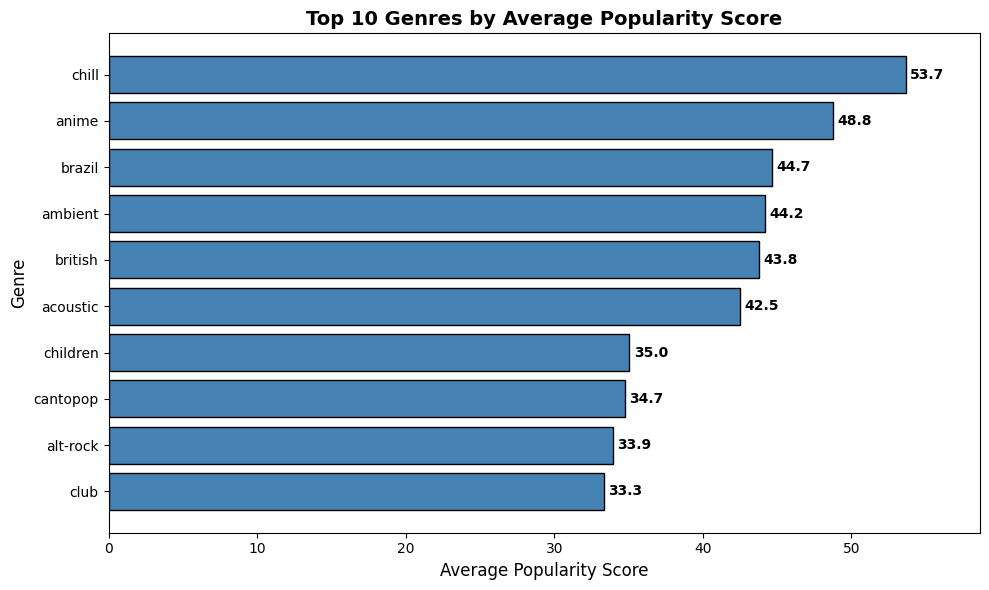

In [28]:
# Chart 1: Top genres by average popularity
generate_and_run_chart("Horizontal bar chart showing the top 10 genres by average popularity score. Sort highest to lowest and put the popularity value at the end of each bar.")

Generated code:
----------------------------------------
import pandas as pd
import matplotlib.pyplot as plt

audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                  'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo']

correlations = spotify_tracks_db[audio_features + ['popularity']].corr()['popularity'].drop('popularity')

correlations_sorted = correlations.sort_values(ascending=True)

colors = ['#2ecc71' if val >= 0 else '#e74c3c' for val in correlations_sorted]

plt.figure(figsize=(10, 6))

bars = plt.barh(correlations_sorted.index, correlations_sorted.values, color=colors, edgecolor='black', linewidth=0.5)

plt.axvline(x=0, color='black', linewidth=0.8, linestyle='-')

for bar, val in zip(bars, correlations_sorted.values):
    x_pos = val + 0.002 if val >= 0 else val - 0.002
    ha = 'left' if val >= 0 else 'right'
    plt.text(x_pos, bar.get_y() + bar.get_height() / 2,
             f'{val:.4f}', va='center', ha=ha, fontsize=9)

plt.

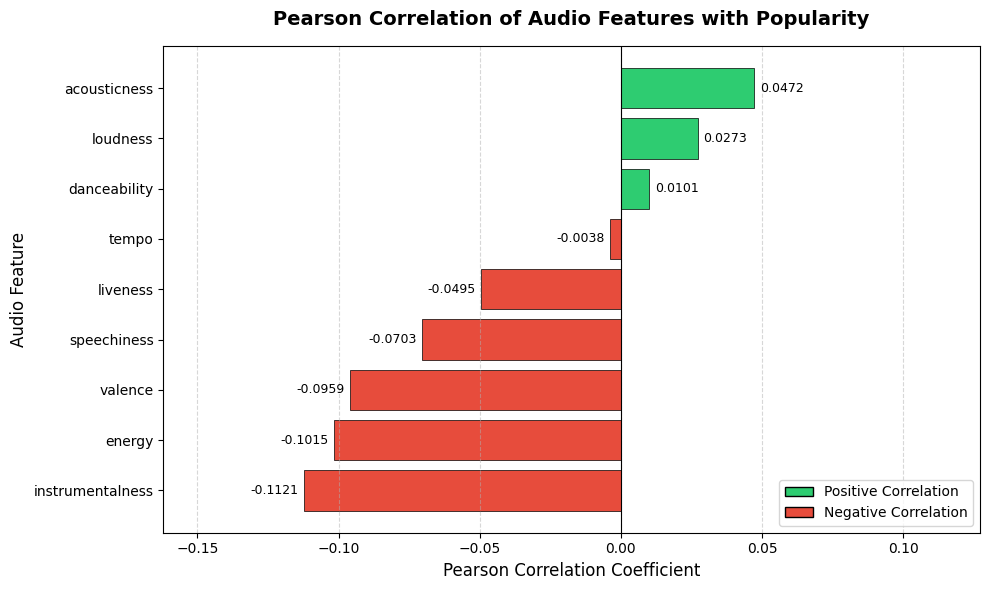

In [29]:
# Chart 2: Audio feature correlations with popularity
generate_and_run_chart("Horizontal bar chart showing the Pearson correlation of each audio feature (danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo) with the popularity score. Sort from most positive to most negative and use different colors for positive and negative values.")

Generated code:
----------------------------------------
import pandas as pd
import numpy as np

popularity_bins = [0, 25, 50, 75, 100]
popularity_labels = ['Emerging\n(0-25)', 'Up and Coming\n(26-50)', 'Mainstream\n(51-75)', 'Chart Topper\n(76-100)']

spotify_tracks_db['popularity_bucket'] = pd.cut(
    spotify_tracks_db['popularity'],
    bins=popularity_bins,
    labels=popularity_labels,
    include_lowest=True
)

features = ['danceability', 'energy', 'valence', 'acousticness']

grouped = spotify_tracks_db.groupby('popularity_bucket', observed=True)[features].mean()

x = np.arange(len(grouped.index))
n_features = len(features)
bar_width = 0.18
offsets = np.linspace(-(n_features - 1) / 2, (n_features - 1) / 2, n_features) * bar_width

colors = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0']

plt.figure(figsize=(10, 6))

for i, (feature, color) in enumerate(zip(features, colors)):
    plt.bar(
        x + offsets[i],
        grouped[feature],
        width=bar_width,
        label=featu

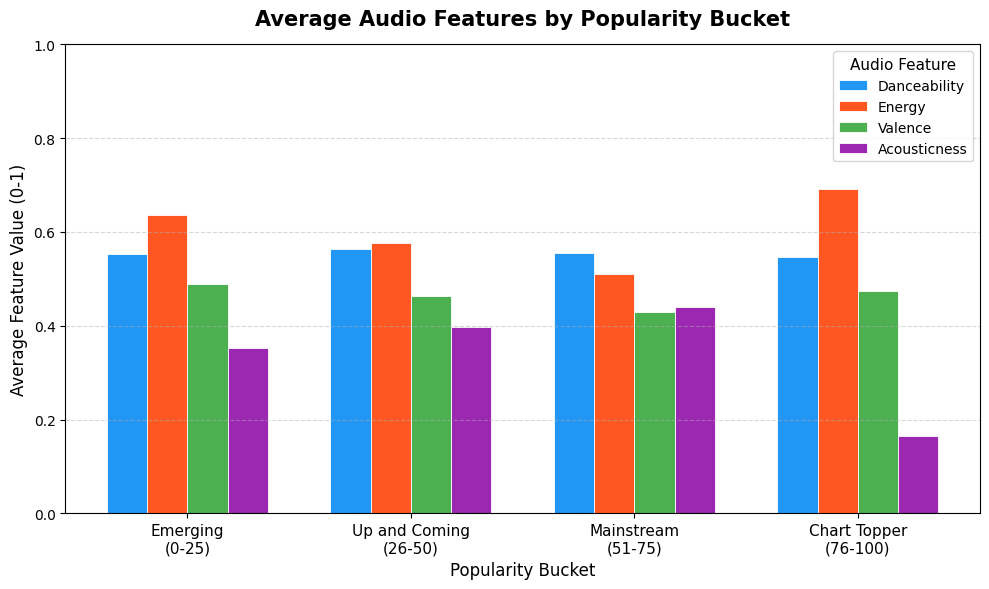

In [30]:
# Chart 3: Average audio features by popularity bucket
generate_and_run_chart("Grouped bar chart showing average danceability, energy, valence, and acousticness for each of the four popularity buckets: emerging (0-25), up and coming (26-50), mainstream (51-75), and chart topper (76-100). Put bucket on the x axis and the four features as grouped bars.")